# Illuminating the Solar Narrative With Data Transparency

In early 2025, Severin Borenstein posted [“Guess What Didn’t Kill Rooftop Solar”](https://energyathaas.wordpress.com/2025/01/27/guess-what-didnt-kill-rooftop-solar/#2484e8ee-f811-4a42-b744-1e17520f6b34-link) to the Energy Institute at Haas blog. In it, he argues that the California rooftop solar industry is quite healthy despite the implementation of the Net Billing Tariff (NBT/NEM 3.0), which drastically lowered compensation for rooftop solar exports. To back this statement he showed a bar graph depicting the “market rebound” after NBT, where sales after NBT seemingly dwarfs sales before NBT for three different time intervals.

Just looking at that bar graph, one would be inclined to believe that rooftop solar sales barely skipped a beat, and in fact sales improved with NBT. But what’s really important to note is that the before and after aggregates pivot around the NBT decision of December 2022, not the NBT implementation of April 2023. To see how this choice of before/after point affects the outcome, let’s plot the number of applications over time, with the time intervals Borenstein aggregates over superimposed.


In [1]:
# First import packages and code
import datetime
import glob
import numpy as np
import numpy_financial as npf
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import data_analysis as data_analysis
import data_visualization as data_vis

import plotly.io as pio
from plotly.offline import init_notebook_mode

pio.renderers.default = "notebook_connected"
init_notebook_mode(connected=True)

In [2]:
# Set paths and load data
data_dir = '/Users/jenny.folkesson/Data/solar/'
dgstats_dir = os.path.join(data_dir, 'applications_20251231/')
archive_dir = os.path.join(data_dir, 'Interconnection_Applications_Dataset_2024-12-31/')

df_total = data_analysis.read_stored_data(dgstats_dir, "dgstats_preprocessed_data.csv", archive_dir)

Reading existing file:  /Users/jenny.folkesson/Data/solar/applications_20251231/dgstats_preprocessed_data.csv


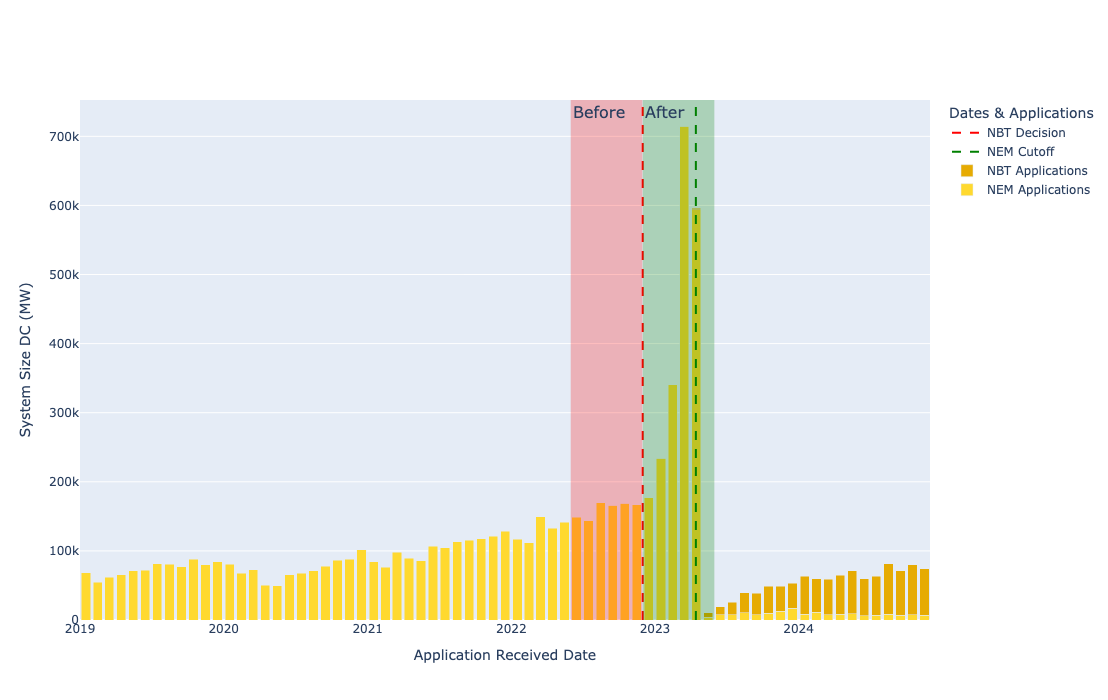

In [3]:
# When Borenstein wrote his blog post, the data in DGStats were from November 30 and earlier so we'll use that here
max_date = "2024-11-30"

dates_borenstein = [{'x0': "2022-06-01", 'x1': "2022-11-30"},
                    {'x0': "2022-12-01", 'x1': "2023-06-01"}]
fig = data_vis.what_didnt_kill_rooftop_solar_graph(df_total, dates=dates_borenstein, max_date=max_date)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "what_didnt_kill_rooftop_solar.png"), scale=5)
fig.write_html(os.path.join(data_dir, "what_didnt_kill_rooftop_solar.html"),
               include_plotlyjs='cdn',
               full_html=False,
               config={"responsive": True}
)

By superimposing one of Borenstein’s Before/After bars on top of actual residential capacity applications, it becomes clear why the NBT decision date is the wrong date for determining the effects of NBT; a vast majority of the “After” capacity in the bar is NEM applications submitted before the NEM cutoff deadline. The figure demonstrates that by including this highlighted area in his 'After' aggregate, Borenstein misrepresents the market’s health. This selection of data obscures, rather than reveals, the true post-NBT impact.

If you’re truly concerned about sales being pulled forward by customers looking to beat the NBT deadline, a more honest way of displaying that would be to compare applications 6-12 months before the NBT decision to applications 6-12 months after the NEM cutoff deadline. This would completely exclude the time between the NBT decision and the NEM 2.0 cutoff deadline, as well as the 6 months before and after. These time intervals are shown in the figrure below.

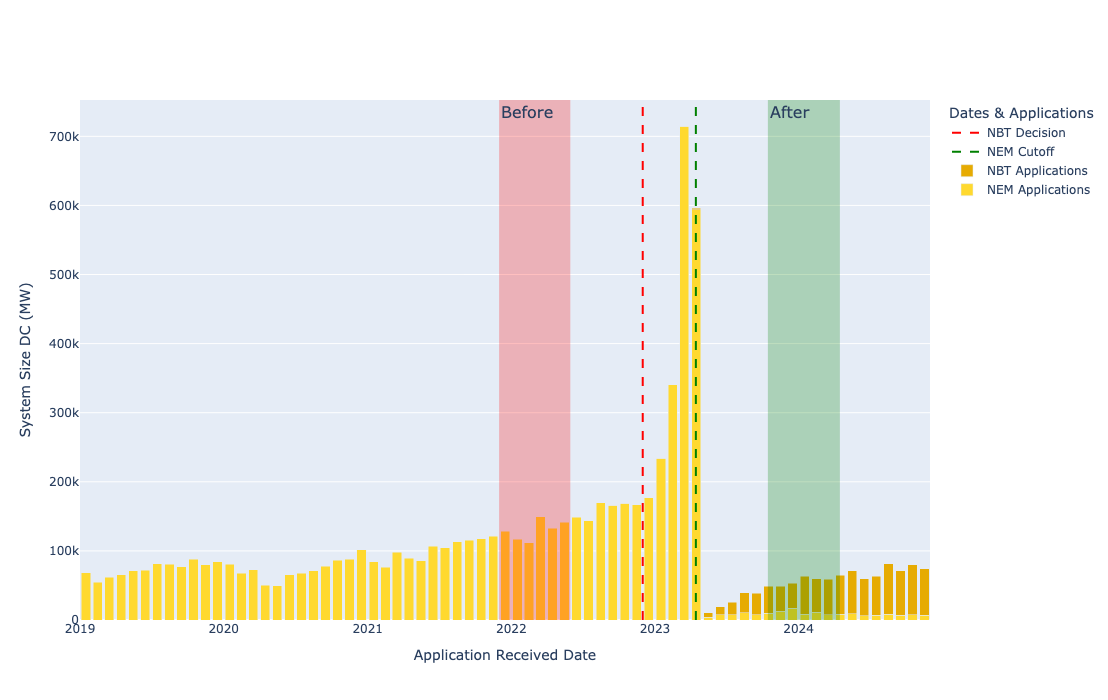

In [4]:
dates_proposed = [{'x0': "2021-12-01", 'x1': "2022-05-31"},
                  {'x0': "2023-10-15", 'x1': "2024-04-15"}]

fig = data_vis.what_didnt_kill_rooftop_solar_graph(df_total, dates=dates_proposed, max_date="2024-11-30")
fig.show()

When using the Before/After time intervals that don't contain the volatility around the NBT decision and the NEM cutoff, we see a completely different picture. Below we compare Borenstein's +-6 Months Before/After bar graph that pivots around the **NBT decision** with the proposed time intervals pictured above, which looks at **6-12 months before the NBT decision and 6-12 months after the NEM cutoff deadline**.

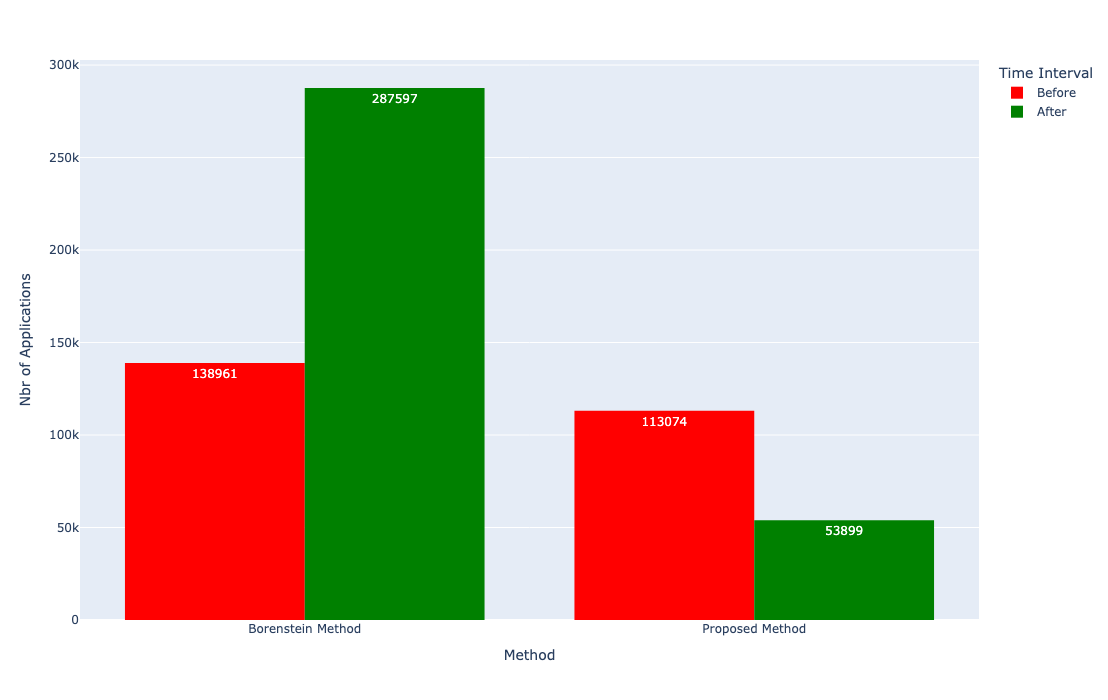

In [5]:
dates_borenstein = [{'x0': "2022-06-01", 'x1': "2022-11-30"},
                    {'x0': "2022-12-01", 'x1': "2023-06-01"}]

dates_proposed = [{'x0': "2021-12-01", 'x1': "2022-05-31"},
                  {'x0': "2023-10-15", 'x1': "2024-04-15"}]

color_map = {
    'Before': 'Red',
    'After': 'Green'
}

df_res = df_total[df_total['Customer Sector'] == 'Residential']
df = df_res[(df_res['App Received Date'] >= dates_borenstein[0]['x0']) &
            (df_res['App Received Date'] <= dates_borenstein[0]['x1'])]
before_bor = df.shape[0]

df = df_res[(df_res['App Received Date'] >= dates_borenstein[1]['x0']) &
            (df_res['App Received Date'] <= dates_borenstein[1]['x1'])]
after_bor = df.shape[0]

df = df_res[(df_res['App Received Date'] >= dates_proposed[0]['x0']) &
            (df_res['App Received Date'] <= dates_proposed[0]['x1'])]
before_pro = df.shape[0]

df = df_res[(df_res['App Received Date'] >= dates_proposed[1]['x0']) &
            (df_res['App Received Date'] <= dates_proposed[1]['x1'])]
after_pro = df.shape[0]

data = {'Time Interval': ['Before', 'After', 'Before', 'After'],
        'Nbr of Applications': [before_bor, after_bor, before_pro, after_pro],
        'Method': ['Borenstein Method', 'Borenstein Method', 'Proposed Method', 'Proposed Method']}
df = pd.DataFrame(data)

fig = px.histogram(df,
                   x="Method",
                   y="Nbr of Applications",
                   color='Time Interval',
                   barmode='group',
                   text_auto='.0f',
                   color_discrete_map=color_map)

fig.update_layout(
    autosize=False,
    width=1000,
    height=700,
    yaxis_title='Nbr of Applications',
)
fig.show()

By using time intervals that do not include the volatility around the NBT decision and the NEM cutoff, a completely different picture emerges. Borenstein's claim that sales in the 6-month period after _the decision_ dwarf sales in the 6 months before is factually true, but it includes the sales spike before the NEM cutoff in the 'After' bar, and leads readers to think that rooftop solar applications doubled due toe the NBT implementation. If we instead use Before/After time intervals that avoid the volatility around the NBT implementation, it becomes clear that rooftop solar applications were actually cut in half.

The integrity of our energy transition depends on how we interpret the signals of our market. When we select benchmarks that mask downturns or aggregate data in ways that obscure volatility, we undermine the very policies designed to foster sustainable growth. At SolarWAVE Action, we believe that transparent, rigorous data analysis is essential to building a credible path forward for clean energy ownership. By holding industry narratives to a higher standard of evidence, we ensure that energy policy decisions are grounded in reality rather than convenient rhetoric.